# sc-GEM Analysis

In [2]:
cd /home/mscs/congfeng4/GuidedStudy/Code/SCOIT/

/home/mscs/congfeng4/GuidedStudy/Code/SCOIT


/public/congfeng4/miniconda3/envs/py39/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
import numpy as np
import seaborn as sns
from umap import UMAP
import pandas as pd
import json
import sys
import matplotlib.pyplot as plt

DATA = 'sc_GEM'
FEATURE = 'walk'

In [4]:
cell_embeddings = np.load(f'./embeddings/{DATA}-{FEATURE}/mymodel_0.npy')
gene_embeddings = np.load(f'./embeddings/{DATA}-{FEATURE}/mymodel_1.npy')
omics_embeddings = np.load(f'./embeddings/{DATA}-{FEATURE}/mymodel_2.npy')

node_names = pd.read_csv(f'./data/{DATA}/nodes.csv')["Name"]
cell_stage = np.unique(pd.read_csv(f"data/{DATA}/cell_stage.csv", header=None))
metadata = json.load(open(f'./data/{DATA}/metadata.json'))

In [5]:
cell_stage, len(cell_stage)

(array(['BJ', 'ES', 'IPS', 'd16T+', 'd16T-', 'd24T+', 'd24T-', 'd8'],
       dtype=object),
 8)

In [6]:
cell_names = node_names[metadata['cell_offset']:].values
cell_names

array(['BJ_1', 'BJ_11', 'BJ_12', 'BJ_13', 'BJ_14', 'BJ_15', 'BJ_17',
       'BJ_18', 'BJ_19', 'BJ_2', 'BJ_21', 'BJ_22', 'BJ_23', 'BJ_24',
       'BJ_25', 'BJ_26', 'BJ_27', 'BJ_28', 'BJ_29', 'BJ_3', 'BJ_31',
       'BJ_32', 'BJ_34', 'BJ_35', 'BJ_37', 'BJ_4', 'BJ_40', 'BJ_41',
       'BJ_43', 'BJ_44', 'BJ_46', 'BJ_5', 'BJ_7', 'BJ_8', 'BJ_9', 'ES_1',
       'ES_10', 'ES_11', 'ES_12', 'ES_13', 'ES_14', 'ES_15', 'ES_16',
       'ES_17', 'ES_18', 'ES_19', 'ES_2', 'ES_20', 'ES_21', 'ES_22',
       'ES_24', 'ES_25', 'ES_3', 'ES_4', 'ES_5', 'ES_6', 'ES_7', 'ES_8',
       'ES_9', 'IPS_1', 'IPS_10', 'IPS_11', 'IPS_12', 'IPS_13', 'IPS_16',
       'IPS_17', 'IPS_19', 'IPS_2', 'IPS_20', 'IPS_21', 'IPS_22',
       'IPS_23', 'IPS_24', 'IPS_25', 'IPS_26', 'IPS_27', 'IPS_3',
       'IPS_31', 'IPS_32', 'IPS_34', 'IPS_35', 'IPS_36', 'IPS_37',
       'IPS_38', 'IPS_39', 'IPS_4', 'IPS_40', 'IPS_44', 'IPS_45', 'IPS_5',
       'IPS_6', 'IPS_7', 'IPS_8', 'd16T+_1', 'd16T+_10', 'd16T+_11',
       'd16T+_12', 'd

In [7]:
def find_cell_stage(cell_id):
    for stage in cell_stage:
        if stage in cell_id:
            return stage
    return '??'

cell_stage_from_id = [find_cell_stage(x) for x in cell_names]

In [8]:
cell_stage_from_id

['BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'BJ',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'ES',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'IPS',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16T+',
 'd16

In [9]:
# Check the stage and name.
assert len(cell_stage_from_id) == len(cell_names)

for stage, name in zip(cell_stage_from_id, cell_names):
    assert stage in name, f'stage={stage}, name={name}'

In [10]:
gene_names = node_names[metadata['gene_offset']: metadata['gene_offset'] + metadata['num_genes']].values
len(gene_names)

61

## Cell Embeddings

Text(0, 0.5, 'UMAP_2')

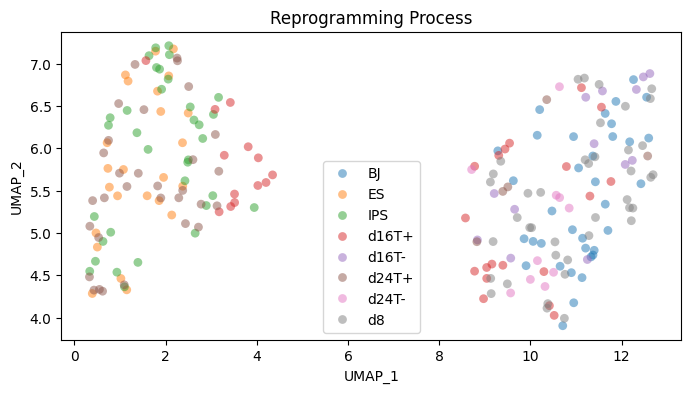

In [11]:
S=40

from umap import UMAP
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
vec = UMAP(n_components=2).fit_transform(cell_embeddings)
sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=cell_stage_from_id, s=S, linewidth=0, alpha=0.5)
plt.legend()
plt.title('Reprogramming Process')
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")


ES, IPS, d24T+ are in one group.

Others are in the other group.

## Heatmaps of gene embeddings

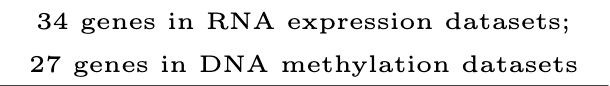

In [12]:
df_gene = pd.DataFrame(gene_embeddings.T, columns=gene_names)
df_gene

,AFP_expr,BMP7_expr,CDH1_expr,CDX2_expr,CER1_expr,DAZL_expr,DNMT3B_expr,DNMT3L_expr,FGF4_expr,FOSL1_expr,...,NXRA8_methy,PIWIL1_methy,PLEKHH3_methy,STON2P1_methy,SULT1A1_methy,TFAP2A_methy,TMEM173_methy,TNNI3_methy,UNC45A_methy,ZNF662_methy
0,0.150733,0.160437,0.200992,0.159735,0.114605,0.391613,0.189005,0.131473,0.171849,0.100368,...,0.167727,0.207725,0.131237,0.154724,0.151781,0.150070,0.173511,0.129356,0.190979,0.142294
1,0.038601,0.050414,0.068403,0.057309,0.098605,1.745389,0.107196,0.105489,0.118229,0.166925,...,0.013172,0.004090,-0.031710,0.017339,0.026970,-0.026004,0.027502,0.012316,0.010761,0.019237
2,0.025534,0.008986,-0.005785,0.006302,-0.016277,-0.893518,-0.016390,-0.037867,0.008596,-0.071024,...,-0.046891,-0.059870,-0.032264,-0.052703,-0.007902,-0.048726,0.017191,-0.021241,-0.040431,-0.031378
3,0.197717,0.151408,0.115760,0.180818,0.171706,-0.589529,0.151726,0.210792,0.143228,0.279271,...,0.040704,0.054861,0.143954,0.104921,0.103673,0.111328,0.069928,0.120325,0.109739,0.097660
4,-0.039511,-0.042799,-0.021693,-0.025313,-0.019184,-0.670107,-0.020261,-0.017994,-0.040078,-0.009012,...,-0.268838,-0.241674,-0.211680,-0.232252,-0.223782,-0.133332,-0.222114,-0.243717,-0.236444,-0.273354
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,0.111335,0.153955,0.162368,0.133142,0.135929,-0.257357,0.109277,0.143325,0.119984,0.050165,...,0.116061,0.141877,0.095763,0.050354,0.083226,0.086135,0.099601,0.057621,0.057474,0.061198
60,-0.029219,-0.076500,-0.097219,-0.080925,-0.072085,-0.014569,-0.097653,-0.048199,-0.116664,-0.094632,...,0.014773,0.004081,0.032382,0.046303,0.035514,0.069477,0.019538,0.014811,0.057858,0.066318
61,0.132378,0.109247,0.105536,0.111104,0.123745,-0.695079,0.089084,0.061056,0.072052,-0.013638,...,-0.172054,-0.133812,-0.078626,-0.215384,-0.188776,-0.109907,-0.129277,-0.168066,-0.163449,-0.147637
62,0.061514,0.130078,0.129407,0.144815,0.126427,-0.907421,0.087343,0.099932,0.093141,-0.104028,...,0.055832,0.067210,-0.070621,-0.016583,0.037832,-0.085885,0.060253,-0.009456,-0.007974,-0.052695


In [13]:
EXPR_LIST = [
    "ZIC3", "KCNQ2", "ZFP42", "OTX2", "SALL4", "NANOG", "SOX2", "CDH1",
    "BMP7", "PRDM14", "DNMT3B", "TFCP2L1", "MMP9", "FGF4", "LEFTY",
    "WNT10B", "OCT4", "ZSCAN18", "CER1", "IGF2", "HAND1", "TFAP2A",
    "TBX3", "FOSL1", "LUM", "TGFBR2"
]
METHY_LIST = [
    "CDH22", "KCNQ2", "NXRA8", "DPPA3", "TMEM173", "COL20A1", "TNNI3",
    "CHL1", "STON2P1", "ALDH3A1", "UNC45A", "SULT1A1", "ZNF662", "LTBR",
    "PIWIL1", "CYBRD1", "FOXD2", "HLX-AS1", "ADAM33", "NFIX", "COL23A1",
    "LY86-AS1", "NFATC1", "PLEKHH3", "TFAP2A", "EPHB3", "AK123759"
]
len(EXPR_LIST), len(METHY_LIST)

(26, 27)

## Heatmap of RNA Expression

In [14]:
df_expr = df_gene.loc[:, df_gene.columns.str.endswith('_expr')].rename(lambda x: x.replace('_expr', ''), axis=1)
df_expr = df_expr.loc[:, EXPR_LIST]

Text(0.5, 1.0, 'Pearson correlations heatmap of RNA expression on sc-GEM')

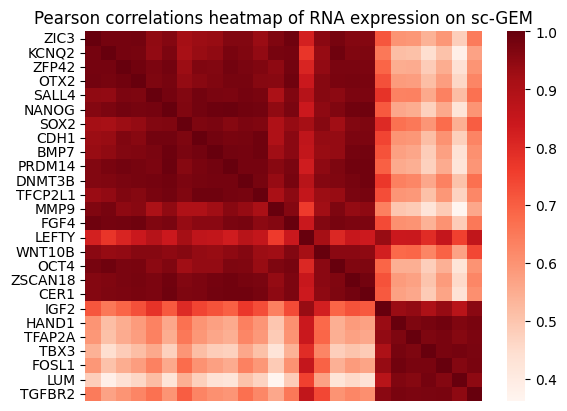

In [15]:
sns.heatmap(df_expr.corr(method='pearson'), cmap='Reds', yticklabels=EXPR_LIST)
plt.xticks([])
plt.title('Pearson correlations heatmap of RNA expression on sc-GEM')

## Heatmap of DNA Methylation

In [16]:
df_methy = df_gene.loc[:, df_gene.columns.str.endswith('_methy')].rename(lambda x: x.replace('_methy', ''), axis=1)
df_methy = df_methy.loc[:, METHY_LIST]

Text(0.5, 1.0, 'Pearson correlations heatmap of DNA methylation on sc-GEM')

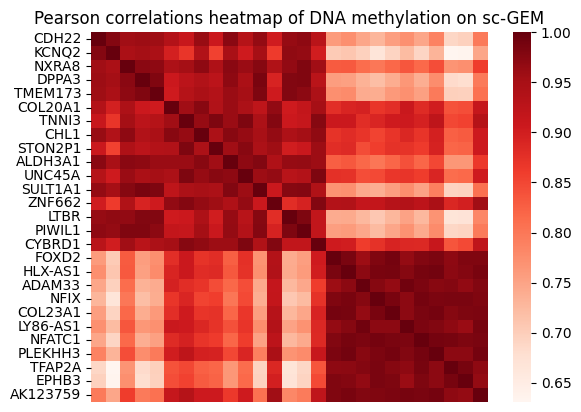

In [17]:
sns.heatmap(df_methy.corr(method='pearson'), cmap='Reds', yticklabels=METHY_LIST)
plt.xticks([])
plt.title('Pearson correlations heatmap of DNA methylation on sc-GEM')

## Projection of pluripotency and somatic gene embeddings

In [18]:
pluripotency = ["ZIC3", "KCNQ2", "ZFP42", "OTX2", "SALL4", "NANOG", "SOX2", "CDH1",
    "BMP7", "PRDM14", "DNMT3B", "TFCP2L1", "MMP9", "FGF4", "LEFTY",
    "WNT10B", "OCT4", "ZSCAN18", "CER1",]

intermedia = [
     'IGF2',
    'HAND1',
]

somatic = [
     'TFAP2A',
     'TBX3',
     'FOSL1',
     'LUM',
     'TGFBR2'
]

In [19]:
pluripotency_gene_df = df_expr.loc[:, pluripotency]
somatic_gene_df = df_expr.loc[:, somatic]

In [20]:
cell_norms = np.linalg.norm(cell_embeddings, axis=1).reshape((-1, 1))
cell_df = pd.DataFrame(cell_embeddings / cell_norms, index=cell_names)


In [21]:
np.sum(cell_df.iloc[0, :].values ** 2) # Cell embeddings normalized.

1.0

In [22]:
special_cell_stages = ['BJ', 'd8', 'd16', 'd24', 'IPS', 'ES']
special_cell_ids = [x for x in cell_df.index if any(stage in x for stage in special_cell_stages)]

In [23]:
special_cells_df = cell_df.loc[special_cell_ids, :].reset_index(names='cell_id')

In [24]:
def find_stage(cell_id):
    for stage in special_cell_stages:
        if stage in cell_id:
            return stage
    return '??'

special_cells_df['stage'] = special_cells_df['cell_id'].apply(find_stage)
special_cells_df = special_cells_df.drop(columns='cell_id').set_index('stage')

### Somatic projection

In [25]:
proj_somatic = (special_cells_df @ somatic_gene_df)
proj_somatic = pd.melt(proj_somatic.reset_index(), id_vars='stage')
proj_somatic


,stage,variable,value
0,BJ,TFAP2A,1.068829
1,BJ,TFAP2A,1.103743
2,BJ,TFAP2A,1.092769
3,BJ,TFAP2A,0.990802
4,BJ,TFAP2A,1.067149
...,...,...,...
1115,d8,TGFBR2,0.922328
1116,d8,TGFBR2,1.023643
1117,d8,TGFBR2,1.039617
1118,d8,TGFBR2,0.965355


Text(0, 0.5, 'Projection value')

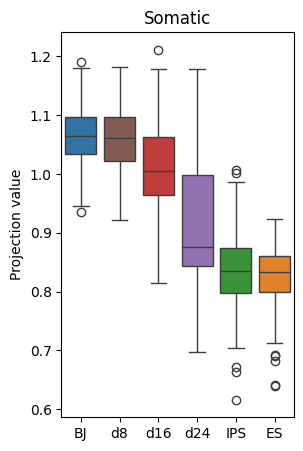

In [26]:
plt.figure(figsize=(3,5))
sns.boxplot(proj_somatic, x='stage', y='value', order=special_cell_stages, hue='stage')
plt.title('Somatic')
plt.xlabel('')
plt.ylabel('Projection value')


### Pluripotency projection

In [27]:
proj_pluripotency = (special_cells_df @ pluripotency_gene_df)
proj_pluripotency = pd.melt(proj_pluripotency.reset_index(), id_vars='stage')
proj_pluripotency


,stage,variable,value
0,BJ,ZIC3,0.834583
1,BJ,ZIC3,0.528123
2,BJ,ZIC3,0.925453
3,BJ,ZIC3,0.828891
4,BJ,ZIC3,0.816367
...,...,...,...
4251,d8,CER1,0.792835
4252,d8,CER1,0.651842
4253,d8,CER1,0.807725
4254,d8,CER1,0.729041


Text(0, 0.5, 'Projection value')

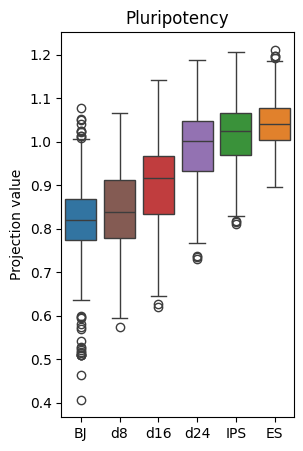

In [28]:
plt.figure(figsize=(3,5))
sns.boxplot(proj_pluripotency, x='stage', y='value', order=special_cell_stages, hue='stage')
plt.title('Pluripotency')
plt.xlabel('')
plt.ylabel('Projection value')

## Cell Clustering

In [29]:
cell_embeddings.shape

(224, 64)

In [30]:
from sklearn.cluster import k_means

_, cluster, _ = k_means(UMAP(3).fit_transform(cell_embeddings / cell_norms), n_clusters=len(cell_stage))
cluster.shape

(224,)

In [31]:
cell_stage_ids = {lbl : i for i, lbl in enumerate(cell_stage)}

In [32]:
cell_stage_label = [cell_stage_ids[y] for y in cell_stage_from_id]

In [33]:
from scipy.optimize import linear_sum_assignment

k = len(cell_stage)
y = cell_stage_label
cluster_ids = cluster

def align_cluster(cluster_ids, y, k):
    # ---------- 3. build cost matrix ----------
    contingency = np.zeros((k, k), dtype=int)
    for c, gt in zip(cluster_ids, y):
        contingency[c, gt] += 1

    # cost = number of mismatches if we map cluster c -> class j
    cost_matrix = contingency.max() - contingency        # or: -contingency

    # ---------- 4. Hungarian ----------
    row_ind, col_ind = linear_sum_assignment(cost_matrix)   # same API as old linear_assignment

    # ---------- 5. remap ----------
    # build a dictionary  old_label -> new_label
    mapping = dict(zip(row_ind, col_ind))
    y_pred_aligned = np.vectorize(mapping.get)(cluster_ids)
    return y_pred_aligned


In [34]:
from sklearn.metrics import normalized_mutual_info_score # NMI
from sklearn.metrics import adjusted_rand_score # ARI
from sklearn.metrics import fowlkes_mallows_score # FMI

In [35]:
def compute_clustering_metrics(y_true, y_pred_aligned):
    return dict(
        NMI = normalized_mutual_info_score(y_true, y_pred_aligned),
        ARI = adjusted_rand_score(y_true, y_pred_aligned),
        FMI = fowlkes_mallows_score(y_true, y_pred_aligned),
    )

In [36]:
y_pred_aligned = align_cluster(cluster, cell_stage_label, len(cell_stage))

In [37]:
metrics = compute_clustering_metrics(y, y_pred_aligned)
metrics


{'NMI': 0.35661194296516974,
 'ARI': 0.1687118820225617,
 'FMI': 0.28385607524428025}

### Baselines

t-SNE, PCA, UMAP.

In [38]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP

from scoit.cell_analysis import RunLeiden, RunLouvain, knn_adj_matrix

In [39]:
from hgnn.hypergraph import HyperGraphCreator
from pathlib import Path

create = HyperGraphCreator({
        'expr': './data/sc_GEM/expression_data.csv',
        'methy': './data/sc_GEM/methylation_data.csv',
    }, cell_key='Cell ID', dataname='sc_GEM', prefix=Path('./data'))

In [40]:
create.load_and_preprocess_data()

Begin to load multi omics data {'expr': './data/sc_GEM/expression_data.csv', 'methy': './data/sc_GEM/methylation_data.csv'}
Load data done, time: 0.010982275009155273
Rename columns
Name: expr, Columns: Index(['ADAM33_expr', 'AFP_expr', 'AK123759_expr', 'ALDH3A1_expr', 'BMP7_expr',
       'CDH1_expr', 'CDH22_expr', 'CDX2_expr', 'CER1_expr', 'CHL1_expr',
       'COL20A1_expr', 'COL23A1_expr', 'CYBRD1_expr', 'DAZL_expr',
       'DNMT3B_expr', 'DNMT3L_expr', 'DPPA3_expr', 'EPHB3_expr', 'FGF4_expr',
       'FOSL1_expr', 'FOXD2_expr', 'HAND1_expr', 'HLX-AS1_expr', 'IGF2_expr',
       'JARID2_expr', 'KCNQ2_expr', 'LEFTY_expr', 'LTBR_expr', 'LUM_expr',
       'LY86-AS1_expr', 'MMP9_expr', 'MYC_expr', 'NANOG_expr', 'NESTIN_expr',
       'NFATC1_expr', 'NFIX_expr', 'NKX2-5_expr', 'NXRA8_expr', 'OCT4_expr',
       'OTX2_expr', 'PIWIL1_expr', 'PLEKHH3_expr', 'PRDM14_expr', 'SALL4_expr',
       'SOX2_expr', 'STON2P1_expr', 'SULT1A1_expr', 'TBX3_expr', 'TFAP2A_expr',
       'TFCP2L1_expr', 'TGFBR2_

In [41]:
assert (create.df.index == cell_names).all().all()


In [42]:
features = create.df.values
features.shape

(224, 61)

In [43]:
baselines = {
    'TSNE' : TSNE,
    'PCA': PCA,
    'UMAP': UMAP,
    'Ours': None, # Placeholder
}

def run_baselines(features, cell_embeddings, dims=3):
    records = []

    for name, method in baselines.items():
        print(name)
        if method is None:
            x = cell_embeddings
        else:
            x = method(n_components=dims).fit_transform(features)

        x_norm = np.linalg.norm(x, axis=1).reshape((-1, 1))
        x = x / x_norm
        _, c, _ = k_means(x, k)
        c_aligned = align_cluster(c, cell_stage_label, k)
        kmeans_metrics = compute_clustering_metrics(cell_stage_label, c_aligned)
        for key, value in kmeans_metrics.items():
            records.append(dict(method=name, metric=key, value=value, task='kmeans'))

        adj = knn_adj_matrix(x)
        c = RunLeiden(adj)
        c_aligned = align_cluster(c, cell_stage_label, k)
        leiden_metrics = compute_clustering_metrics(cell_stage_label, c_aligned)
        for key, value in leiden_metrics.items():
            records.append(dict(method=name, metric=key, value=value, task='leiden'))

    return pd.DataFrame.from_records(records)


Text(0, 0.5, 'UMAP_2')

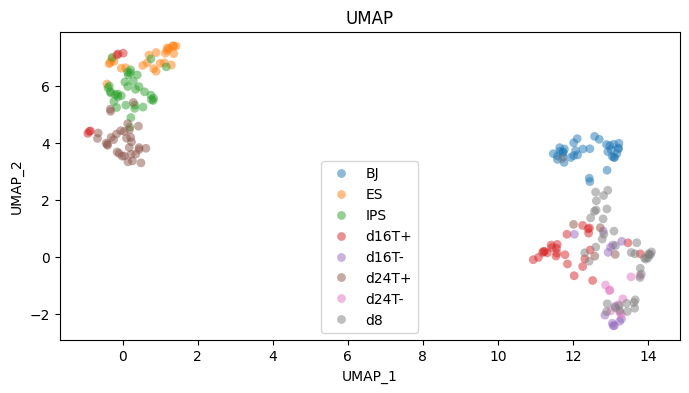

In [44]:
S=40

from umap import UMAP
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
vec = UMAP(n_components=2).fit_transform(features)
sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=cell_stage_from_id, s=S, linewidth=0, alpha=0.5)
plt.legend()
plt.title('UMAP')
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")


Text(0, 0.5, 'TSNE_2')

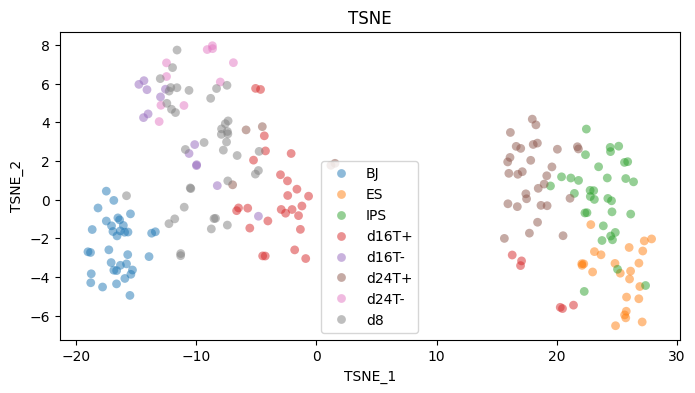

In [45]:
S=40

from umap import UMAP
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
vec = TSNE(n_components=2).fit_transform(features)
sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=cell_stage_from_id, s=S, linewidth=0, alpha=0.5)
plt.legend()
plt.title('TSNE')
plt.xlabel("TSNE_1")
plt.ylabel("TSNE_2")


### K-means performance

In [46]:
df_cluster = run_baselines(features, cell_embeddings)

TSNE
PCA
UMAP
Ours


Text(0, 0.5, '')

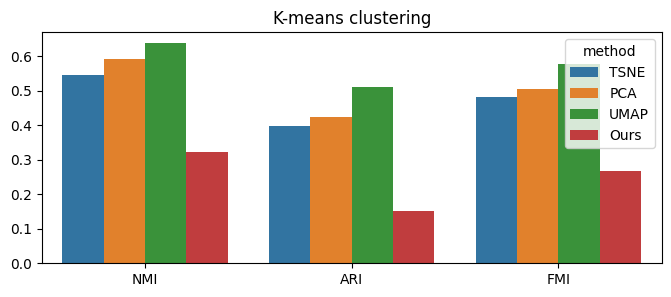

In [47]:
plt.figure(figsize=(8,3))
sns.barplot(df_cluster[df_cluster.task == 'kmeans'], x='metric', y='value', hue='method')
plt.title('K-means clustering')
plt.xlabel('')
plt.ylabel('')

### Leiden community detection

Text(0, 0.5, '')

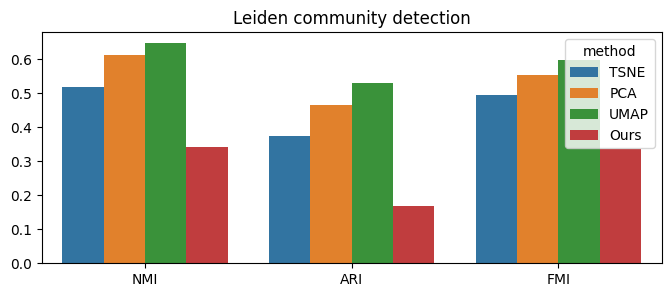

In [48]:
plt.figure(figsize=(8,3))
sns.barplot(df_cluster[df_cluster.task == 'leiden'], x='metric', y='value', hue='method')
plt.title('Leiden community detection')
plt.xlabel('')
plt.ylabel('')